[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Loading Dataset...

First 5 rows:
   review_id                                             review sentiment  \
0          1  Really impressed with this air purifier, custo...  Positive   
1          2  The keyboard arrived on time and works flawles...  Positive   
2          3  The smartwatch does what it says, though the d...   Neutral   
3          4  The tablet matches the description, neither im...   Neutral   
4          5  Terrible vacuum cleaner, broke after just two ...  Negative   

                                      cleaned_review  
0  really impressed air purifier customer service...  
1  keyboard arrived time work flawlessly five sta...  
2       smartwatch say though design feel basic cost  
3  tablet match description neither impressed dis...  
4  terrible vacuum cleaner broke two day use wast...  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ---

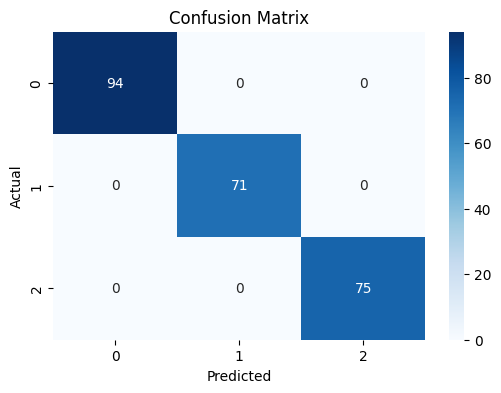


===== CUSTOM PREDICTIONS =====
Review: This product is amazing and worth buying
Prediction: Negative

Review: Terrible product, waste of money
Prediction: Negative

Review: The product is okay
Prediction: Neutral

========== OBSERVATIONS ==========

1. Product reviews were successfully cleaned and preprocessed.
2. Stopword removal reduced unnecessary words.
3. TF-IDF converted text into machine-readable numerical vectors.
4. Logistic Regression performed sentiment classification effectively.
5. Confusion matrix helped analyze misclassifications.
6. The model can predict custom review sentiments.

Project Completed Successfully.


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

nltk.download('stopwords')


print("Loading Dataset...")

df = pd.read_csv("/content/product_reviews_cleaned.csv")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nColumns:")
print(df.columns)


df = df[['review', 'sentiment']]

df.dropna(inplace=True)

print("\nDataset Shape:", df.shape)


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_review'] = df['review'].apply(clean_text)

print("\nAfter Cleaning:")
print(df[['review', 'clean_review']].head())


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['clean_review'] = df['clean_review'].apply(remove_stopwords)

print("\nAfter Stopword Removal:")
print(df[['review', 'clean_review']].head())


print("\nConverting text into numerical vectors using TF-IDF...")

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print("Feature Matrix Shape:", X.shape)


print("\nSplitting dataset into train and test...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



print("\nTraining Logistic Regression Model...")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed.")



print("\nEvaluating model...")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n===== PERFORMANCE METRICS =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nGenerating Confusion Matrix...")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



def predict_sentiment(review):
    review = clean_text(review)
    review = remove_stopwords(review)

    review_vector = vectorizer.transform([review])

    prediction = model.predict(review_vector)

    return prediction[0]


print("\n===== CUSTOM PREDICTIONS =====")
review1 = "This product is amazing and worth buying"
review2 = "Terrible product, waste of money"
review3 = "The product is okay"

print("Review:", review1)
print("Prediction:", predict_sentiment(review1))

print("\nReview:", review2)
print("Prediction:", predict_sentiment(review2))

print("\nReview:", review3)
print("Prediction:", predict_sentiment(review3))


print("\n========== OBSERVATIONS ==========")
print("""
1. Product reviews were successfully cleaned and preprocessed.
2. Stopword removal reduced unnecessary words.
3. TF-IDF converted text into machine-readable numerical vectors.
4. Logistic Regression performed sentiment classification effectively.
5. Confusion matrix helped analyze misclassifications.
6. The model can predict custom review sentiments.
""")

print("Project Completed Successfully.")